# 한국어 위키피디아 데이터셋 분석

이 노트북은 한국어 위키피디아 XML 덤프 파일(`kowiki-20251220-pages-articles-multistream.xml`)을 분석합니다.

## 분석 목표
- 기본 통계 파악 (페이지 수, 네임스페이스 분포, 텍스트 길이 등)
- 위키텍스트 태그 분석
- 언어 분석 (한글/영문/숫자/기호 비율)
- 데이터 품질 확인
- 정제 작업을 위한 권장사항 도출


In [2]:
# 필요한 라이브러리 import
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 프로젝트 루트 경로 추가
project_root = Path().resolve().parent.parent  # notebooks/experiments -> notebooks -> 프로젝트 루트
sys.path.insert(0, str(project_root))

# 데이터 경로
data_path = project_root / 'data' / 'kowiki-20251220-pages-articles-multistream.xml'

print(f"프로젝트 루트: {project_root}")
print(f"데이터 경로: {data_path}")
print(f"데이터 파일 존재: {data_path.exists()}")


프로젝트 루트: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07
데이터 경로: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/kowiki-20251220-pages-articles-multistream.xml
데이터 파일 존재: True


## 1. 데이터 로딩 및 기본 정보


In [4]:
from src.data.wikipedia_parser import collect_statistics, get_namespace_name

# 파일 크기 확인
if data_path.exists():
    file_size_gb = data_path.stat().st_size / (1024 ** 3)
    print(f"파일 크기: {file_size_gb:.2f} GB")
    
    # 샘플링을 사용하여 빠른 분석 (전체 분석은 시간이 오래 걸림)
    # 전체 분석을 원하면 sample_rate=1.0, max_pages=None으로 설정
    print("\n데이터 분석 시작...")
    print("참고: 전체 데이터 분석은 시간이 오래 걸릴 수 있습니다.")
    print("샘플링을 사용하여 빠르게 분석합니다. (sample_rate=0.1, max_pages=10000)")
    
    # 샘플링 분석 
#     def collect_statistics(
#     xml_path: str,
#     max_pages: Optional[int] = None,
#     sample_rate: float = 1.0

    stats = collect_statistics(
        str(data_path),
        # max_pages= 10000,  # 처음 10,000개 페이지만 분석
        # sample_rate=0.1  # 10% 샘플링
    )
    
    print(f"\n분석 완료! 총 {stats['total_pages']}개 페이지 분석")
else:
    print("데이터 파일을 찾을 수 없습니다!")
    stats = None


파일 크기: 5.60 GB

데이터 분석 시작...
참고: 전체 데이터 분석은 시간이 오래 걸릴 수 있습니다.
샘플링을 사용하여 빠르게 분석합니다. (sample_rate=0.1, max_pages=10000)


파싱 중...: 21it [00:00, 207.43it/s]

XML 파일 열기 중... (파일 크기: 5.60 GB)
XML 파서 초기화 중...
파싱 시작...


파싱 중...: 2157147it [15:51, 2266.48it/s] 


분석 완료! 총 2157147개 페이지 분석


## 2. 기본 통계 분석


In [5]:
if stats:
    print("=" * 60)
    print("기본 통계")
    print("=" * 60)
    print(f"총 페이지 수: {stats['total_pages']:,}")
    print(f"빈 페이지: {stats['empty_count']:,} ({stats['empty_count']/stats['total_pages']*100:.2f}%)")
    print(f"리다이렉트 페이지: {stats['redirect_count']:,} ({stats['redirect_count']/stats['total_pages']*100:.2f}%)")
    print(f"스텁 페이지 (짧은 문서): {stats['stub_count']:,} ({stats['stub_count']/stats['total_pages']*100:.2f}%)")
    print(f"실제 콘텐츠 페이지: {stats['total_pages'] - stats['empty_count'] - stats['redirect_count']:,}")
    
    if stats['text_lengths']:
        print(f"\n텍스트 길이 통계:")
        print(f"  평균: {np.mean(stats['text_lengths']):,.0f} 문자")
        print(f"  중앙값: {np.median(stats['text_lengths']):,.0f} 문자")
        print(f"  최소: {np.min(stats['text_lengths']):,} 문자")
        print(f"  최대: {np.max(stats['text_lengths']):,} 문자")
        print(f"  표준편차: {np.std(stats['text_lengths']):,.0f} 문자")
    
    if stats['word_counts']:
        print(f"\n단어 수 통계:")
        print(f"  평균: {np.mean(stats['word_counts']):,.0f} 단어")
        print(f"  중앙값: {np.median(stats['word_counts']):,.0f} 단어")
        print(f"  최소: {np.min(stats['word_counts']):,} 단어")
        print(f"  최대: {np.max(stats['word_counts']):,} 단어")


기본 통계
총 페이지 수: 2,157,147
빈 페이지: 91 (0.00%)
리다이렉트 페이지: 871,923 (40.42%)
스텁 페이지 (짧은 문서): 1,426,019 (66.11%)
실제 콘텐츠 페이지: 1,285,133

텍스트 길이 통계:
  평균: 1,273 문자
  중앙값: 53 문자
  최소: 1 문자
  최대: 1,536,744 문자
  표준편차: 5,730 문자

단어 수 통계:
  평균: 118 단어
  중앙값: 1 단어
  최소: 0 단어
  최대: 144,522 단어


In [4]:
if stats and stats['namespace_counts']:
    print("=" * 60)
    print("네임스페이스별 페이지 분포")
    print("=" * 60)
    
    # 네임스페이스별 통계
    ns_data = []
    for ns, count in stats['namespace_counts'].most_common():
        ns_name = get_namespace_name(ns)
        percentage = count / stats['total_pages'] * 100
        ns_data.append({
            '네임스페이스': ns_name,
            '번호': ns,
            '페이지 수': count,
            '비율 (%)': f"{percentage:.2f}%"
        })
    
    ns_df = pd.DataFrame(ns_data)
    print(ns_df.to_string(index=False))


네임스페이스별 페이지 분포
네임스페이스  번호  페이지 수 비율 (%)
    문서   0   7399 73.99%
    분류  14   2040 20.40%
     틀  10    374  3.74%
  위키백과   4    125  1.25%
    파일   6     46  0.46%
위키프로젝트 102     12  0.12%
 기타(8)   8      3  0.03%
   도움말  12      1  0.01%


## 3. 시각화


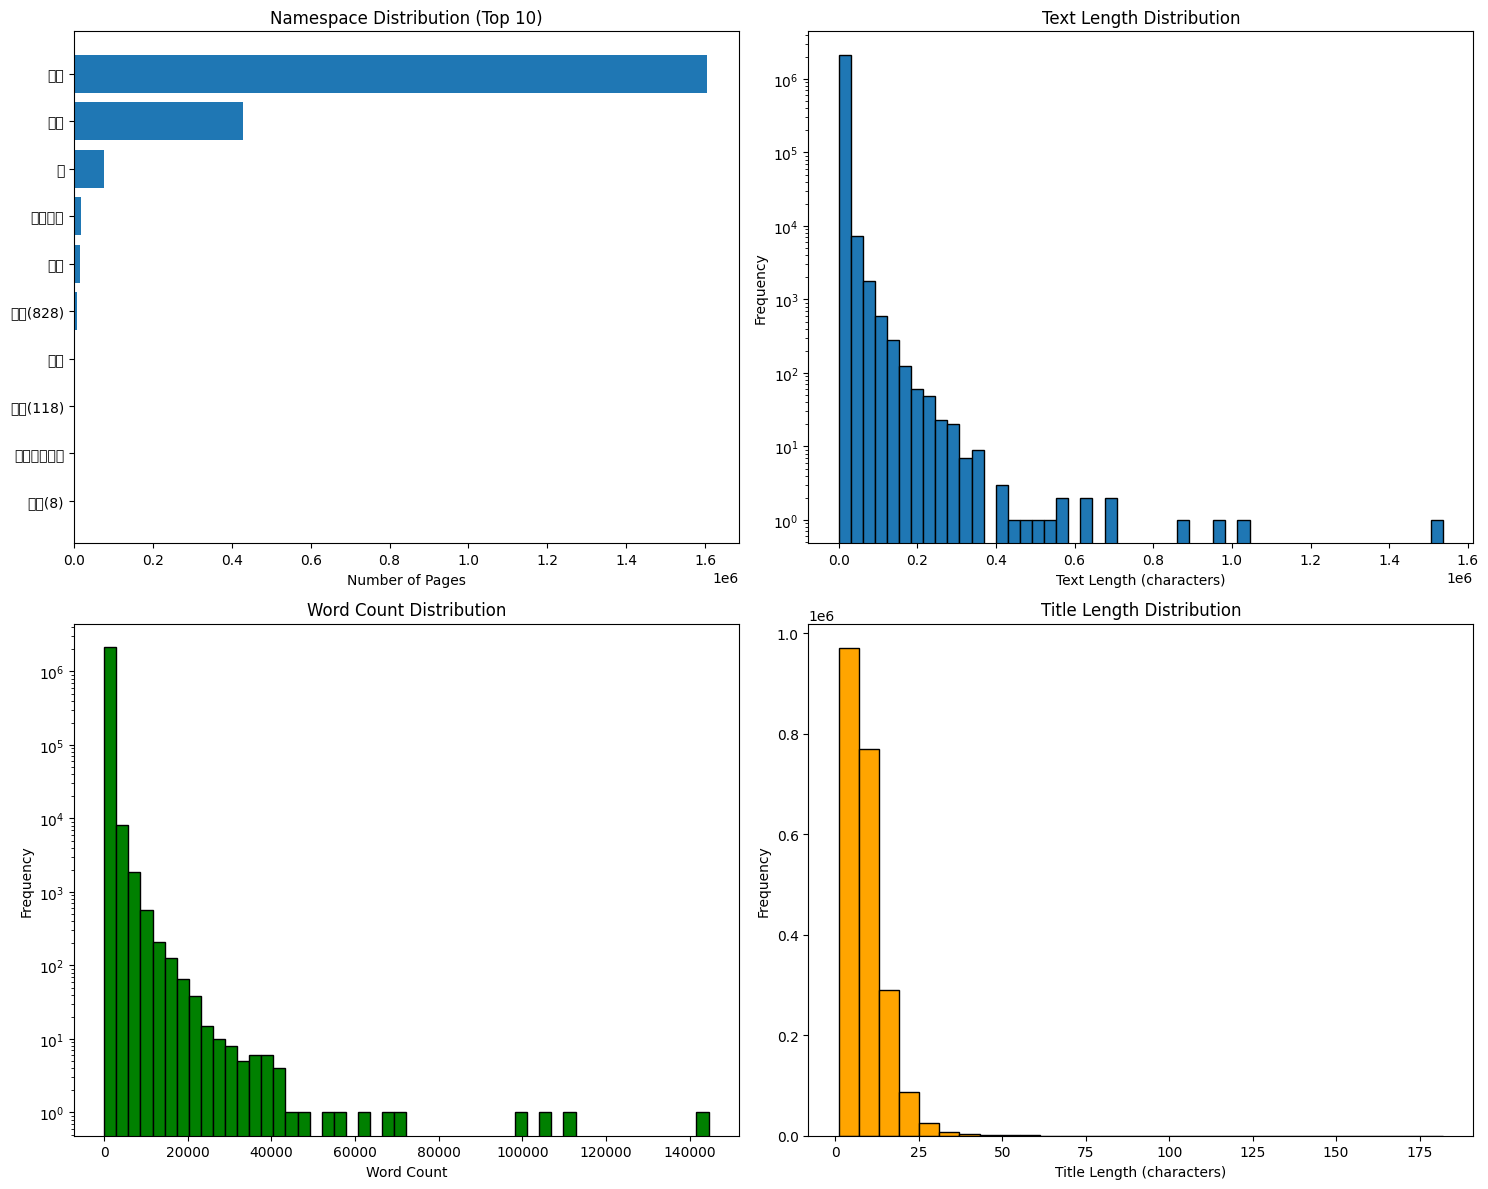

In [6]:
if stats:
    # 시각화 설정
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. 네임스페이스별 분포 (Namespace Distribution)
    if stats['namespace_counts']:
        ns_names = [get_namespace_name(ns) for ns, _ in stats['namespace_counts'].most_common(10)]
        ns_counts = [count for _, count in stats['namespace_counts'].most_common(10)]
        
        axes[0, 0].barh(ns_names, ns_counts)
        axes[0, 0].set_xlabel('Number of Pages')  # 페이지 수
        axes[0, 0].set_title('Namespace Distribution (Top 10)')  # 네임스페이스별 페이지 분포 (상위 10개)
        axes[0, 0].invert_yaxis()
    
    # 2. 텍스트 길이 분포 (Text Length Distribution)
    if stats['text_lengths']:
        axes[0, 1].hist(stats['text_lengths'], bins=50, edgecolor='black')
        axes[0, 1].set_xlabel('Text Length (characters)')  # 텍스트 길이 (문자)
        axes[0, 1].set_ylabel('Frequency')  # 빈도
        axes[0, 1].set_title('Text Length Distribution')  # 텍스트 길이 분포
        axes[0, 1].set_yscale('log')
    
    # 3. 단어 수 분포 (Word Count Distribution)
    if stats['word_counts']:
        axes[1, 0].hist(stats['word_counts'], bins=50, edgecolor='black', color='green')
        axes[1, 0].set_xlabel('Word Count')  # 단어 수
        axes[1, 0].set_ylabel('Frequency')  # 빈도
        axes[1, 0].set_title('Word Count Distribution')  # 단어 수 분포
        axes[1, 0].set_yscale('log')
    
    # 4. 제목 길이 분포 (Title Length Distribution)
    if stats['title_lengths']:
        axes[1, 1].hist(stats['title_lengths'], bins=30, edgecolor='black', color='orange')
        axes[1, 1].set_xlabel('Title Length (characters)')  # 제목 길이 (문자)
        axes[1, 1].set_ylabel('Frequency')  # 빈도
        axes[1, 1].set_title('Title Length Distribution')  # 제목 길이 분포
    
    plt.tight_layout()
    plt.show()


## 4. 상세 분석 - 위키텍스트 태그


위키텍스트 태그 분석
   태그       총 개수 페이지당 평균
내부 링크 34,265,800   15.88
  템플릿 11,682,210    5.42
   분류  4,785,100    2.22
  기울임  3,402,216    1.58
   제목  3,345,849    1.55
   굵게  2,567,723    1.19
 참고문헌  2,314,390    1.07
외부 링크  1,000,339    0.46
   파일    523,998    0.24
    표    274,200    0.13


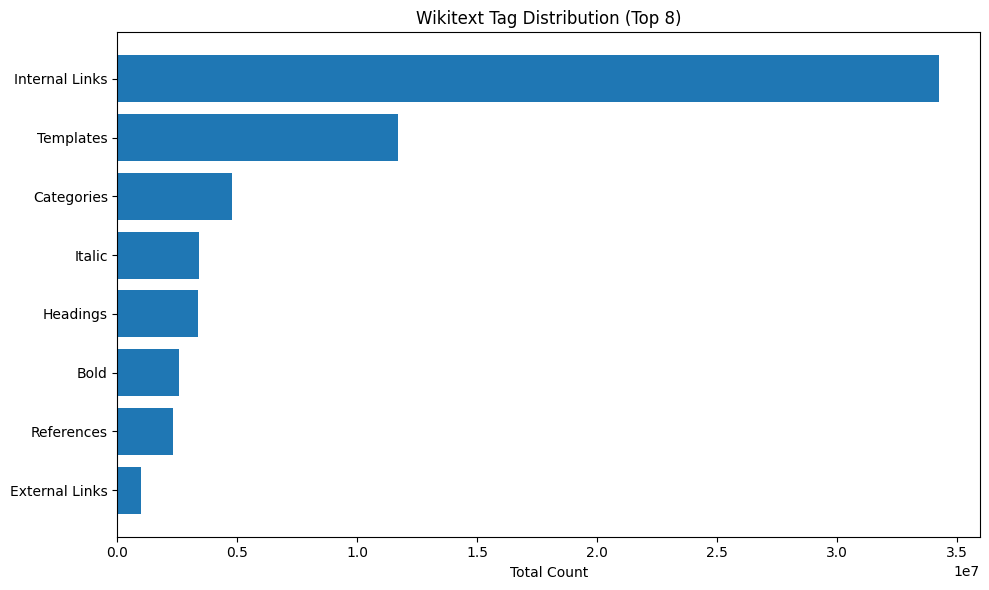

In [7]:
if stats and stats['tag_counts']:
    print("=" * 60)
    print("위키텍스트 태그 분석")
    print("=" * 60)
    
    tag_names = {
        'internal_links': '내부 링크',
        'external_links': '외부 링크',
        'templates': '템플릿',
        'categories': '분류',
        'files': '파일',
        'headings': '제목',
        'bold': '굵게',
        'italic': '기울임',
        'references': '참고문헌',
        'tables': '표',
    }
    
    tag_data = []
    for tag, count in sorted(stats['tag_counts'].items(), key=lambda x: x[1], reverse=True):
        tag_name_kr = tag_names.get(tag, tag)
        avg_per_page = count / stats['total_pages'] if stats['total_pages'] > 0 else 0
        tag_data.append({
            '태그': tag_name_kr,
            '총 개수': f"{count:,}",
            '페이지당 평균': f"{avg_per_page:.2f}"
        })
    
    tag_df = pd.DataFrame(tag_data)
    print(tag_df.to_string(index=False))
    
    # 태그 분포 시각화 (Wikitext Tag Distribution)
    if tag_data:
        fig, ax = plt.subplots(figsize=(10, 6))
        # 영어 라벨로 변환
        tag_labels_en = {
            '내부 링크': 'Internal Links',
            '외부 링크': 'External Links',
            '템플릿': 'Templates',
            '분류': 'Categories',
            '파일': 'Files',
            '제목': 'Headings',
            '굵게': 'Bold',
            '기울임': 'Italic',
            '참고문헌': 'References',
            '표': 'Tables'
        }
        tag_labels_kr = [tag_names.get(tag, tag) for tag, _ in sorted(stats['tag_counts'].items(), key=lambda x: x[1], reverse=True)[:8]]
        tag_labels = [tag_labels_en.get(label, label) for label in tag_labels_kr]
        tag_values = [count for _, count in sorted(stats['tag_counts'].items(), key=lambda x: x[1], reverse=True)[:8]]
        ax.barh(tag_labels, tag_values)
        ax.set_xlabel('Total Count')  # 총 개수
        ax.set_title('Wikitext Tag Distribution (Top 8)')  # 위키텍스트 태그 분포 (상위 8개)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()


## 5. 언어 분석


언어 분석
총 문자 수: 2,746,914,054

문자 유형별 분포:
  한글: 805,726,212 (29.33%)
  영문: 706,698,645 (25.73%)
  숫자: 209,914,881 (7.64%)
  기호: 589,263,983 (21.45%)
  공백: 0 (0.00%)


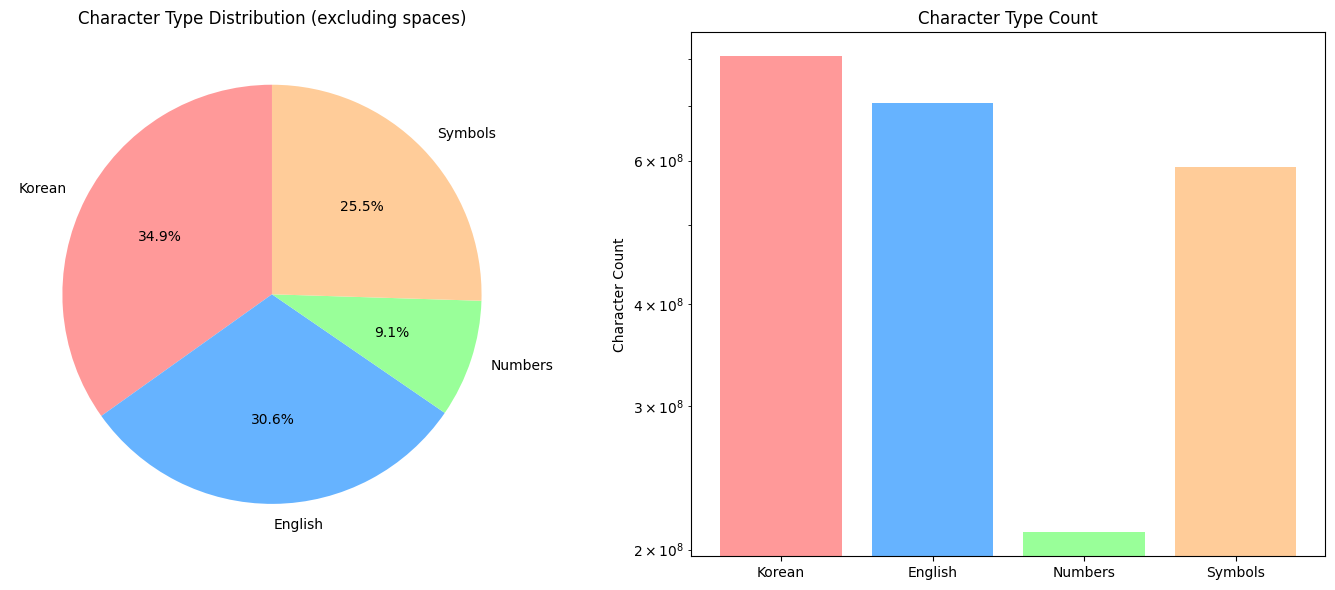

In [8]:
if stats and stats['language_stats']['total'] > 0:
    print("=" * 60)
    print("언어 분석")
    print("=" * 60)
    
    lang_stats = stats['language_stats']
    total = lang_stats['total']
    
    print(f"총 문자 수: {total:,}")
    print(f"\n문자 유형별 분포:")
    print(f"  한글: {lang_stats['korean']:,} ({lang_stats['korean']/total*100:.2f}%)")
    print(f"  영문: {lang_stats['english']:,} ({lang_stats['english']/total*100:.2f}%)")
    print(f"  숫자: {lang_stats['numbers']:,} ({lang_stats['numbers']/total*100:.2f}%)")
    print(f"  기호: {lang_stats['symbols']:,} ({lang_stats['symbols']/total*100:.2f}%)")
    print(f"  공백: {lang_stats.get('spaces', 0):,} ({lang_stats.get('spaces', 0)/total*100:.2f}%)")
    
    # 파이 차트 (Pie Chart)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 문자 유형별 분포 (공백 제외) - Character Type Distribution (excluding spaces)
    labels = ['Korean', 'English', 'Numbers', 'Symbols']  # 한글, 영문, 숫자, 기호
    sizes = [
        lang_stats['korean'],
        lang_stats['english'],
        lang_stats['numbers'],
        lang_stats['symbols']
    ]
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    
    ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax1.set_title('Character Type Distribution (excluding spaces)')  # 문자 유형별 분포 (공백 제외)
    
    # 막대 그래프 (Bar Chart)
    ax2.bar(labels, sizes, color=colors)
    ax2.set_ylabel('Character Count')  # 문자 수
    ax2.set_title('Character Type Count')  # 문자 유형별 개수
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()


## 6. 샘플 페이지 확인


In [12]:
if stats and stats['sample_pages']:
    print("=" * 60)
    print("샘플 페이지 (처음 5개)")
    print("=" * 60)
    
    for i, page in enumerate(stats['sample_pages'][:5], 1):
        print(f"\n[{i}] {page['title']}")
        print(f"    네임스페이스: {get_namespace_name(page['ns'])} ({page['ns']})")
        print(f"    텍스트 길이: {page['text_length']:,} 문자")
        print(f"    미리보기:")
        print(f"    {page['text_preview']}")
        print("-" * 60)


샘플 페이지 (처음 5개)

[1] 위키백과:대문
    네임스페이스: 위키백과 (4)
    텍스트 길이: 12,696 문자
    미리보기:
    <templatestyles src="틀:대문/styles.css" />
<div class="main-box main-top" style="flex: 10;">
	<div class="main-top-left">
		<span style="font-size: 1.8rem; margin-top: 0; margin-bottom: .1em;">[[위키백과:소개|<span style="color: black; font-weight: bold;">위키백과</span>]]</span>
		<p style="font-size: 1rem; margin-top: .1em; margin-bottom: 1em;">우리 모두가 만들어가는 자유 백과사전<span class="nomobile"><br />문서 [[위키백과:통계|{{말풍선|1=<span style="color: #246ad3;">'''{{NUMBEROFARTICLES}}'''</span>|style=text-decoration: none; ...
------------------------------------------------------------

[2] 지미 카터
    네임스페이스: 문서 (0)
    텍스트 길이: 42,233 문자
    미리보기:
    {{대통령 정보
| 이름 = 지미 카터
| 원어명 = {{lang|en|Jimmy Carter}}
| 그림 = JimmyCarterPortrait.jpg
| 크기 = 300px
| 설명 = 
| 국가 = 미국
| 대수 = 39
| 취임일 = 1977년 1월 20일
| 퇴임일 = 1981년 1월 20일
| 부통령 = [[월터 먼데일]]
| 전임 = 제럴드 포드
| 전임대수 = 38
| 후임 = 로널드 레이건
| 후임대수 = 40
<!--주지사-->| 국가2 = [[조지아주]]
| 명칭2 = [[주지사]]


In [11]:
page

{'title': '도움말:도움말',
 'ns': 12,
 'text_preview': '{{다른 뜻|위키백과:도움말 이름공간||위키백과의 이름공간}}\n{{도움말 문서 머리말}}\n<div class="cp_contentsbox" style="border:1px solid #dcdcdc; margin: 0.5em 0 0 0; vertical-align:top; padding: 1em; overflow: auto;">\n{{단축|백:도|백:도움|백:도움말}}\n<span style="font-size: 1.8rem; margin-top: 0; margin-bottom: 0.1em;">\'\'\'위키백과 도움말\'\'\'</span>\n<p style="font-size: 0.95rem; margin-top: .1em; margin-bottom: .1em;">위키백과에 처음 오셨나요? \'\'\'[[도움말:소개|소개와 길라잡이]]에 방문해 주세요\'\'\'. <br /> 위키백과에 관해 풀리지 않은 궁금하신 점이 있으시다면 궁금한 점을 \'\'\'[[백:질문방|질문방]]\'\'\'에서 물어보세요.</p> \n\n<d...',
 'text_length': 3134}

## 7. 결론 및 정제 방향 제안


In [10]:
if stats:
    print("=" * 60)
    print("정제 작업을 위한 권장사항")
    print("=" * 60)
    
    recommendations = []
    
    # 1. 네임스페이스 필터링
    main_article_ns = stats['namespace_counts'].get(0, 0)
    if main_article_ns > 0:
        recommendations.append(
            f"✓ 네임스페이스 0 (일반 문서)만 사용: {main_article_ns:,}개 페이지"
        )
    
    # 2. 리다이렉트 제거
    if stats['redirect_count'] > 0:
        recommendations.append(
            f"✓ 리다이렉트 페이지 제거: {stats['redirect_count']:,}개"
        )
    
    # 3. 빈 페이지 제거
    if stats['empty_count'] > 0:
        recommendations.append(
            f"✓ 빈 페이지 제거: {stats['empty_count']:,}개"
        )
    
    # 4. 스텁 페이지 필터링
    if stats['stub_count'] > 0:
        recommendations.append(
            f"✓ 스텁 페이지 필터링 고려: {stats['stub_count']:,}개 (너무 짧은 문서)"
        )
    
    # 5. 텍스트 길이 필터링
    if stats['text_lengths']:
        median_length = np.median(stats['text_lengths'])
        recommendations.append(
            f"✓ 최소 텍스트 길이 설정 고려: 중앙값 {median_length:.0f} 문자 기준"
        )
    
    # 6. 위키텍스트 정제
    if stats['tag_counts']:
        recommendations.append(
            "✓ 위키텍스트 마크업 제거 (링크, 템플릿, 카테고리 등)"
        )
        recommendations.append(
            "✓ HTML 태그 제거"
        )
        recommendations.append(
            "✓ 참고문헌 및 각주 제거"
        )
    
    # 7. 언어 필터링
    if stats['language_stats']['total'] > 0:
        korean_ratio = stats['language_stats']['korean'] / stats['language_stats']['total']
        if korean_ratio < 0.5:
            recommendations.append(
                f"⚠ 한글 비율이 낮음 ({korean_ratio*100:.1f}%), 한글 중심 문서 필터링 고려"
            )
    
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")
    
    print("\n" + "=" * 60)
    print("예상 정제 후 데이터 크기")
    print("=" * 60)
    
    # 네임스페이스 0만 사용, 리다이렉트/빈 페이지 제거
    filtered_count = stats['total_pages'] - stats['redirect_count'] - stats['empty_count']
    # 네임스페이스 0이 아닌 것들 제거 (대략적 추정)
    ns_0_count = stats['namespace_counts'].get(0, 0)
    estimated_articles = ns_0_count - stats['redirect_count'] - stats['empty_count']
    
    print(f"원본 페이지 수: {stats['total_pages']:,}")
    print(f"예상 정제 후 문서 수: {estimated_articles:,}")
    print(f"정제율: {(1 - estimated_articles/stats['total_pages'])*100:.1f}%")


정제 작업을 위한 권장사항
1. ✓ 네임스페이스 0 (일반 문서)만 사용: 1,604,804개 페이지
2. ✓ 리다이렉트 페이지 제거: 871,923개
3. ✓ 빈 페이지 제거: 91개
4. ✓ 스텁 페이지 필터링 고려: 1,426,019개 (너무 짧은 문서)
5. ✓ 최소 텍스트 길이 설정 고려: 중앙값 53 문자 기준
6. ✓ 위키텍스트 마크업 제거 (링크, 템플릿, 카테고리 등)
7. ✓ HTML 태그 제거
8. ✓ 참고문헌 및 각주 제거
9. ⚠ 한글 비율이 낮음 (29.3%), 한글 중심 문서 필터링 고려

예상 정제 후 데이터 크기
원본 페이지 수: 2,157,147
예상 정제 후 문서 수: 732,790
정제율: 66.0%
